# 3 · Comparing a quantity across categories

**Analytical question:** how does a measure — its average, its whole
distribution, or just the count — differ between groups?

## Charts in this notebook

| Function | Level | Dataset | In one line |
|---|---|---|---|
| `stripplot` | axes | tips | every observation as a point, random jitter (dots overlap) |
| `swarmplot` | axes | tips | same data, points arranged so none overlap |
| `boxplot` | axes | tips | median, quartiles and outliers per category |
| `violinplot` | axes | titanic | a mirrored KDE — the full distribution shape per category |
| `boxenplot` | axes | diamonds | like a boxplot but resolves the tails (large samples) |
| `pointplot` | axes | titanic | an estimate per category joined by lines, to read the trend |
| `barplot` | axes | penguins | an aggregate (mean by default) per category, with error bars |
| `countplot` | axes | titanic | how many rows fall in each category |
| `catplot` | figure | tips | any of the above, faceted across subsets |

**Method:** one minimal, idiomatic example per function. Each ends by saving a
PNG to `images/`. The first eight come in families — the notes focus on which to
reach for.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

penguins = sns.load_dataset("penguins")
tips = sns.load_dataset("tips")
titanic = sns.load_dataset("titanic")
diamonds = sns.load_dataset("diamonds")

CLASS_ORDER = ["First", "Second", "Third"]

## `stripplot`

Axes-level. A scatter along a categorical axis: one dot per observation, placed
with a small **random** horizontal jitter. Dots are allowed to overlap.

The next two plots use the *same data* (`tips`, total bill by day) so the
difference between the two is visible directly.

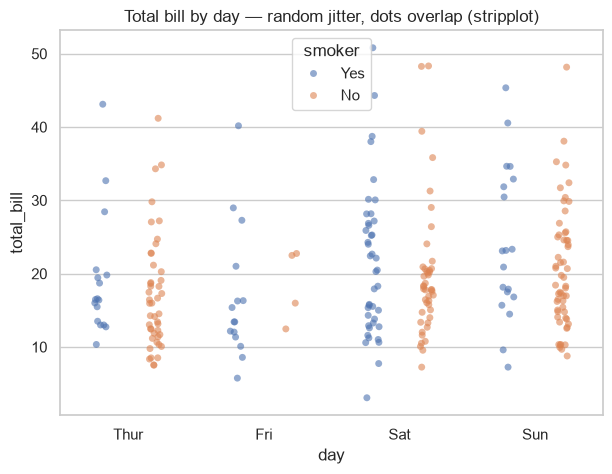

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.stripplot(
    data=tips,
    x="day", y="total_bill",
    hue="smoker", dodge=True, alpha=0.6,
    ax=ax,
)
ax.set_title("Total bill by day — random jitter, dots overlap (stripplot)")
fig.savefig("images/3_stripplot.png", dpi=150, bbox_inches="tight")

**Best for**

- Showing *all* the data along a category axis when you don't need every point separated — a quick "what's actually in each group".
- Works at **any N**: it never refuses, it just gets denser. `alpha` and `jitter` manage the crowding; `dodge=True` splits `hue` groups.
- As a thin layer *under* a box or violin, so the summary and the raw points sit together.

**`stripplot` vs `swarmplot`** — same goal (draw every point), opposite method:

| | `stripplot` | `swarmplot` |
|---|---|---|
| Horizontal position | **random** jitter | **computed** so no two points touch |
| Overlap | yes | never |
| Read density from width? | no | yes — the pile is wider where there are more points |
| N per category | unlimited (turns into a smear) | a few hundred, then it warns and drops points |
| Cost | trivial | can be slow |

Reach for `stripplot` when N is large or it's just a backing layer; reach for
`swarmplot` when N is small and the shape of the pile is the point.

[`stripplot` docs](https://seaborn.pydata.org/generated/seaborn.stripplot.html)

## `swarmplot`

Axes-level. The **same points** as the strip plot above, but each one is shifted
along the category axis by a *computed* amount so that none overlap. The width of
the resulting "swarm" at any height is proportional to how many points sit there —
so the outline reads like a discrete violin.

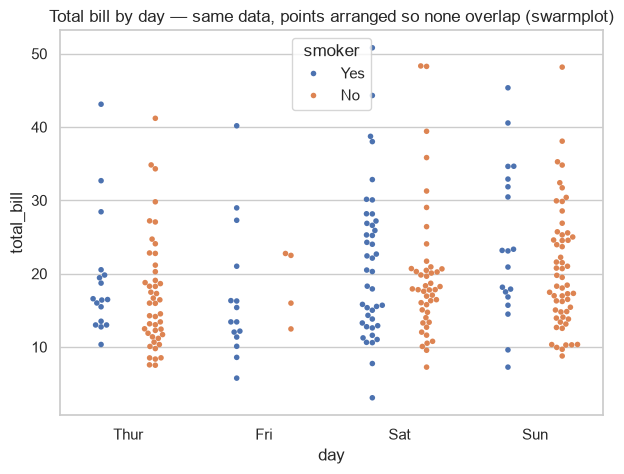

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.swarmplot(
    data=tips,
    x="day", y="total_bill",
    hue="smoker", dodge=True, size=4,
    ax=ax,
)
ax.set_title("Total bill by day — same data, points arranged so none overlap (swarmplot)")
fig.savefig("images/3_swarmplot.png", dpi=150, bbox_inches="tight")

**Best for**

- The most honest categorical view when it fits: every point drawn, none hidden, and the density is legible from the swarm's width — no binning, no smoothing.
- Small N — a few hundred points per category at most.
- **Not** for large N: seaborn prints `X% of the points cannot be placed` and silently drops them, so the picture is quietly wrong. Switch to `violinplot`, or `boxplot` with a `stripplot` layer.

Compared with the strip plot above: `stripplot` is faster and unbounded but its
random jitter hides how many points overlap; `swarmplot` shows that exactly, at
the cost of a hard ceiling on N.

[`swarmplot` docs](https://seaborn.pydata.org/generated/seaborn.swarmplot.html)

## `boxplot`

Axes-level. The five-number summary per category: median line, inter-quartile
box, whiskers to 1.5×IQR, points beyond that.

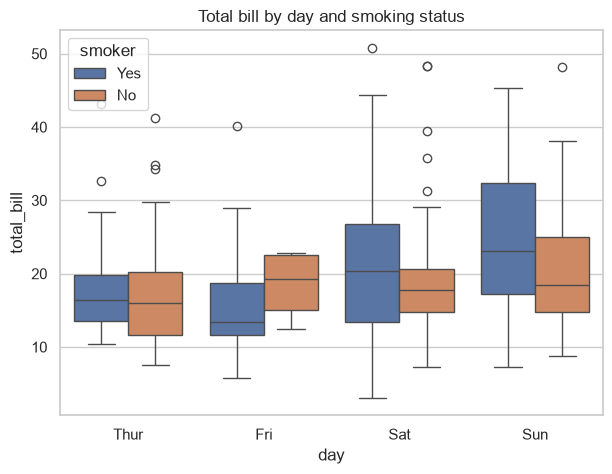

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=tips,
    x="day", y="total_bill",
    hue="smoker",
    ax=ax,
)
ax.set_title("Total bill by day and smoking status")
fig.savefig("images/3_boxplot.png", dpi=150, bbox_inches="tight")

**Best for**

- Comparing centre and spread across many groups at any N — compact, familiar, robust to outliers.
- Quick read of skew (median off-centre in the box) and of which groups overlap.
- **Not** able to show *shape*: a two-humped group and a flat one can produce the same box. Overlay a `stripplot`, or use `violinplot`.

[`boxplot` docs](https://seaborn.pydata.org/generated/seaborn.boxplot.html)

## `violinplot`

Axes-level. A KDE mirrored into a "violin" for each category — the distribution
shape a boxplot can't show. `split=True` packs two `hue` levels into one violin.

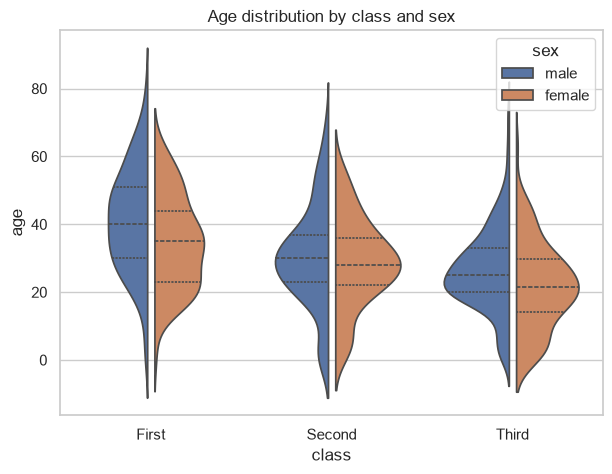

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(
    data=titanic,
    x="class", y="age", order=CLASS_ORDER,
    hue="sex", split=True, gap=0.1, inner="quart",
    ax=ax,
)
ax.set_title("Age distribution by class and sex")
sns.move_legend(ax, "upper right")
fig.savefig("images/3_violinplot.png", dpi=150, bbox_inches="tight")

**Best for**

- Showing skew and multiple modes across categories — the reason to prefer it over a boxplot.
- `split=True` for a tight two-group comparison; `inner="quart" | "box" | "stick" | "point"` picks the summary drawn inside.
- **Not** for small groups (the KDE invents shape), and it bulges past hard limits — the violins above dip below age 0, which is impossible. Pass `cut=0` to clip at the observed min/max.

[`violinplot` docs](https://seaborn.pydata.org/generated/seaborn.violinplot.html)

## `boxenplot`

Axes-level. A boxplot extended with successively smaller boxes for
further-out quantiles, so the *tails* of a large sample are drawn instead of
dumped as a cloud of outliers. (Also called a letter-value plot.)

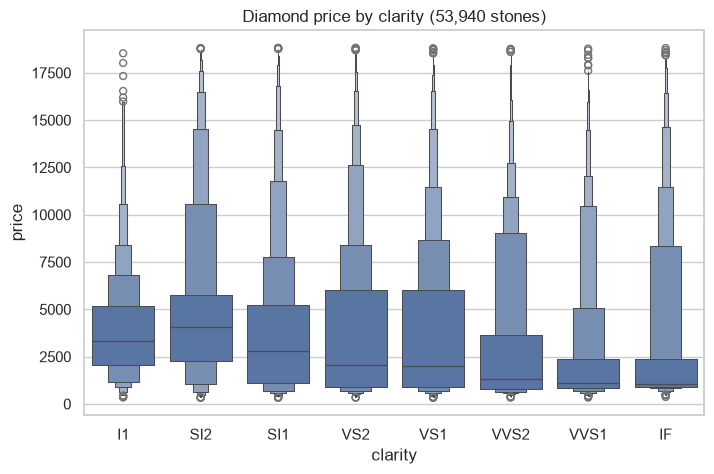

In [6]:
CLARITY_ORDER = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]  # worst -> best

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxenplot(
    data=diamonds,
    x="clarity", y="price", order=CLARITY_ORDER,
    color="C0",
    ax=ax,
)
ax.set_title(f"Diamond price by clarity ({len(diamonds):,} stones)")
fig.savefig("images/3_boxenplot.png", dpi=150, bbox_inches="tight")

**Best for**

- Large samples (thousands+) where a boxplot's single whisker throws away most of the interesting tail.
- Seeing how skew and tail-heaviness change across categories.
- **Not** worth it for small N — the extra boxes are just noise; a plain `boxplot` says the same thing.

[`boxenplot` docs](https://seaborn.pydata.org/generated/seaborn.boxenplot.html)

## `pointplot`

Axes-level. One estimate per category (mean by default) with an error bar,
connected by lines across the category axis.

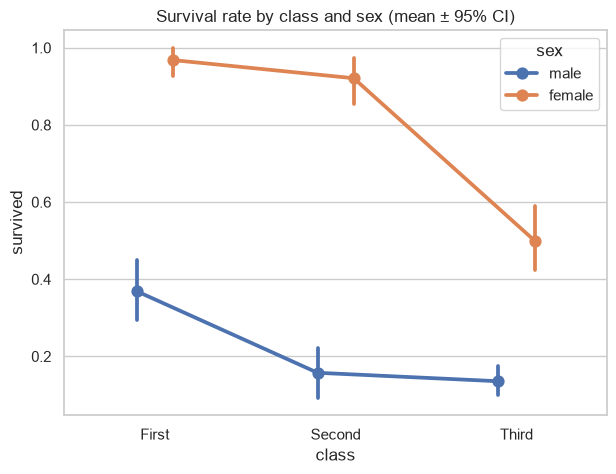

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.pointplot(
    data=titanic,
    x="class", y="survived", order=CLASS_ORDER,
    hue="sex", dodge=0.2, errorbar=("ci", 95),
    ax=ax,
)
ax.set_title("Survival rate by class and sex (mean ± 95% CI)")
fig.savefig("images/3_pointplot.png", dpi=150, bbox_inches="tight")

**Best for**

- Reading a *trend* across an ordered category, and interaction effects — do the `hue` lines stay parallel, or cross?
- A 0/1 outcome: the mean is a rate, so this is survival probability with a CI.
- **Not** for nominal categories where "between" has no meaning — the connecting line implies an order that isn't there. Use `barplot`.

[`pointplot` docs](https://seaborn.pydata.org/generated/seaborn.pointplot.html)

## `barplot`

Axes-level. One aggregate per category drawn from zero (mean by default; set
`estimator`), with an error bar.

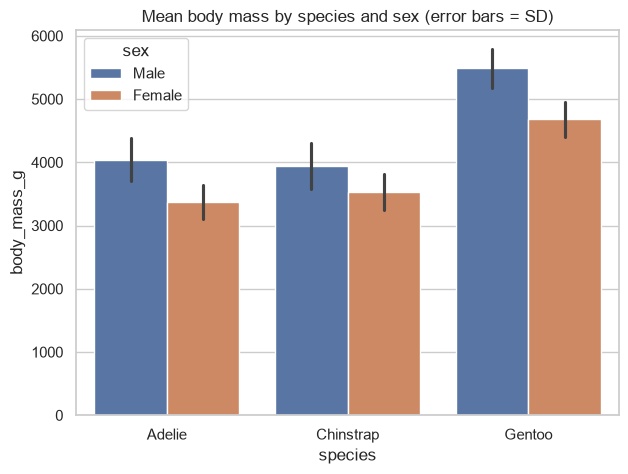

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=penguins,
    x="species", y="body_mass_g",
    hue="sex", errorbar="sd",
    ax=ax,
)
ax.set_title("Mean body mass by species and sex (error bars = SD)")
fig.savefig("images/3_barplot.png", dpi=150, bbox_inches="tight")

**Best for**

- Comparing a handful of summary values when the zero baseline is meaningful.
- Swappable statistic: `estimator="median"`, `estimator="sum"`, etc., with a matching `errorbar`.
- **Not** for showing a distribution (it's one number per bar), and misleading when the quantity has no true zero — use `pointplot` then.

[`barplot` docs](https://seaborn.pydata.org/generated/seaborn.barplot.html)

## `countplot`

Axes-level. A `barplot` whose statistic is "how many rows" — one bar per
category or per `hue` combination. The categorical cousin of `histplot`.

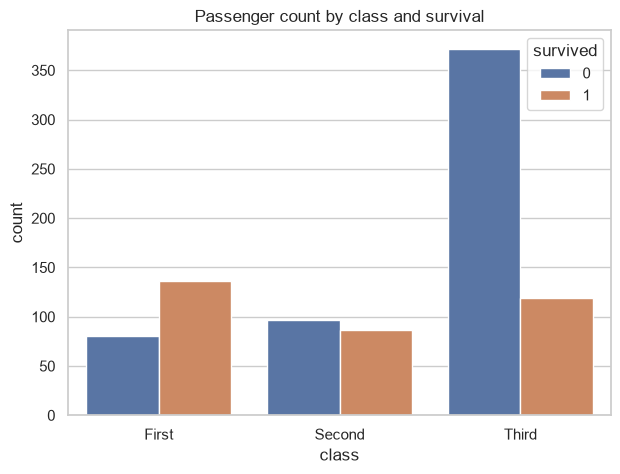

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(
    data=titanic,
    x="class", order=CLASS_ORDER,
    hue="survived",
    ax=ax,
)
ax.set_title("Passenger count by class and survival")
fig.savefig("images/3_countplot.png", dpi=150, bbox_inches="tight")

**Best for**

- Frequencies of a categorical variable, and simple two-way cross-tabs via `hue`.
- A fast "how is my data distributed across groups?" before any analysis.
- **Not** for an already-aggregated table — then it's `barplot(x=..., y="count")`.

[`countplot` docs](https://seaborn.pydata.org/generated/seaborn.countplot.html)

## `catplot`

Figure-level. The faceting front-end to all eight functions above, via
`kind="strip" | "swarm" | "box" | "violin" | "boxen" | "point" | "bar" | "count"`.

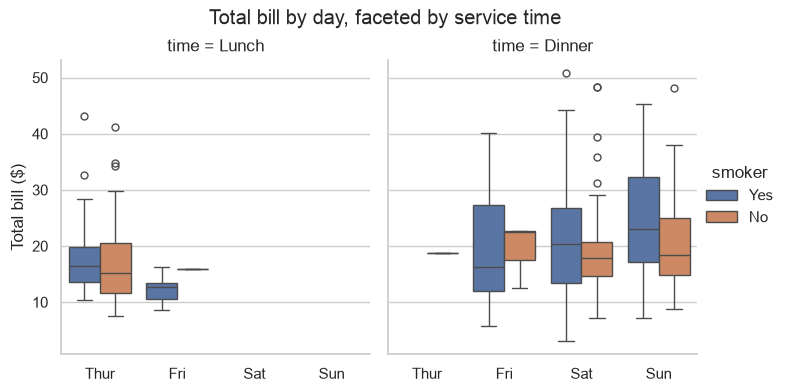

In [10]:
g = sns.catplot(
    data=tips,
    x="day", y="total_bill",
    hue="smoker", col="time",
    kind="box", height=4, aspect=0.9,
)
g.set_axis_labels("", "Total bill ($)")
g.figure.suptitle("Total bill by day, faceted by service time", y=1.03)
g.savefig("images/3_catplot.png", dpi=150, bbox_inches="tight")

**Best for**

- "Does this comparison hold across subgroups?" — `row` / `col` build the grid, `kind=` picks the plot.
- Figure-level housekeeping: shared axes and a single legend outside the panels.
- **Not** for one panel on a specific `Axes` — call the axes-level function directly.

[`catplot` docs](https://seaborn.pydata.org/generated/seaborn.catplot.html)